# Benchmarking `libjpeg-turbo` 📊

# 📈 Data Visualization & Analysis

Now we will plot the collected data to understand the results. We will focus on:
1.  **Rate-Distortion:** How do quality metrics (like VMAF) change with file size?
2.  **Quality vs. File Size:** How does the `-quality` setting impact file size for different subsampling methods?
3.  **Encoding Performance:** Which DCT method is fastest? How does resolution affect encoding time?
4.  **Decoding Performance:** How does resolution affect decoding time?

In [ ]:
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("C:/Users/s248508/Pictures/benchmark-result/libjpeg-turbo_schif_results_1280x720.csv")
df.head()

,img_name,subsampling,quality,dct_algorithm,entropy_algorithm,restart_interval,enc_avg_time_milliseconds,enc_avg_fps,enc_avg_mps,dec_avg_time_milliseconds,dec_avg_fps,dec_avg_mps,compressed_size_bytes,compression_ratio,bpp,psnr,ssim
0,r0b5b85d0t.rgb,444,0,int,huffman,0,4.102,243.769,224.657200,2.876,347.708,320.447291,40573,68.143839,0.352196,25.1758,0.612947
1,r0b5b85d0t.rgb,444,0,int,huffman,8,4.011,249.289,229.744653,3.012,332.001,305.972032,46377,59.615758,0.402578,25.1758,0.612947
2,r0b5b85d0t.rgb,444,0,fast,huffman,0,3.965,252.237,232.461937,2.705,369.728,340.741453,40565,68.157278,0.352127,25.1241,0.581557
3,r0b5b85d0t.rgb,444,0,fast,huffman,8,3.938,253.916,234.009004,2.850,350.850,323.343461,46370,59.624757,0.402517,25.1241,0.581557
4,r0b5b85d0t.rgb,444,0,float,huffman,0,4.931,202.804,186.904516,3.523,283.867,261.611568,40570,68.148878,0.352170,25.1189,0.581461


## Encoding Parameters vs. quality metrics

In [ ]:
plt.style.use('default')

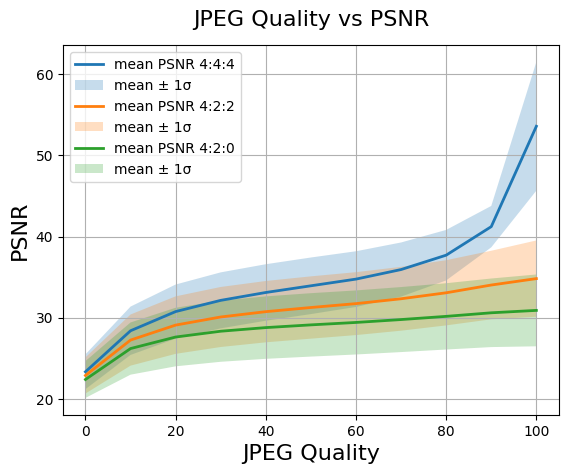

In [6]:
# Aggregate per quality across experiments
stats_444 = (
    df[df["subsampling"] == 444].groupby("quality", as_index=False)["psnr"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_444["quality"].to_numpy()
m_444 = stats_444["mean"].to_numpy()
s_444 = stats_444["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_444 = np.nan_to_num(s_444, nan=0.0)

stats_422 = (
    df[df["subsampling"] == 422].groupby("quality", as_index=False)["psnr"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_422 = stats_422["mean"].to_numpy()
s_422 = stats_422["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_422 = np.nan_to_num(s_422, nan=0.0)

stats_420 = (
    df[df["subsampling"] == 420].groupby("quality", as_index=False)["psnr"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_420 = stats_420["mean"].to_numpy()
s_420 = stats_420["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_420 = np.nan_to_num(s_420, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs PSNR", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("PSNR", fontsize=16)
ax.grid(True)

ax.plot(x, m_444, label="mean PSNR 4:4:4", linewidth=2)
ax.fill_between(x, m_444 - s_444, m_444 + s_444, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_422, label="mean PSNR 4:2:2", linewidth=2)
ax.fill_between(x, m_422 - s_422, m_422 + s_422, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_420, label="mean PSNR 4:2:0", linewidth=2)
ax.fill_between(x, m_420 - s_420, m_420 + s_420, alpha=0.25, label="mean ± 1σ")


ax.legend()
plt.show()

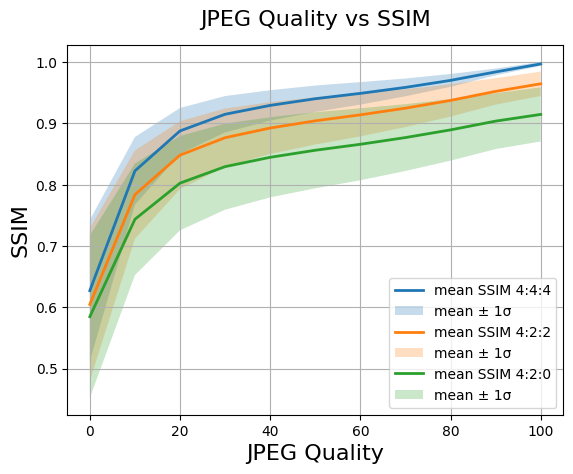

In [7]:
# Aggregate per quality across experiments
stats_444 = (
    df[df["subsampling"] == 444].groupby("quality", as_index=False)["ssim"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_444["quality"].to_numpy()
m_444 = stats_444["mean"].to_numpy()
s_444 = stats_444["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_444 = np.nan_to_num(s_444, nan=0.0)

stats_422 = (
    df[df["subsampling"] == 422].groupby("quality", as_index=False)["ssim"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_422 = stats_422["mean"].to_numpy()
s_422 = stats_422["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_422 = np.nan_to_num(s_422, nan=0.0)

stats_420 = (
    df[df["subsampling"] == 420].groupby("quality", as_index=False)["ssim"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_420 = stats_420["mean"].to_numpy()
s_420 = stats_420["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_420 = np.nan_to_num(s_420, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs SSIM", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("SSIM", fontsize=16)
ax.grid(True)

ax.plot(x, m_444, label="mean SSIM 4:4:4", linewidth=2)
ax.fill_between(x, m_444 - s_444, m_444 + s_444, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_422, label="mean SSIM 4:2:2", linewidth=2)
ax.fill_between(x, m_422 - s_422, m_422 + s_422, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_420, label="mean SSIM 4:2:0", linewidth=2)
ax.fill_between(x, m_420 - s_420, m_420 + s_420, alpha=0.25, label="mean ± 1σ")

ax.legend()
plt.show()

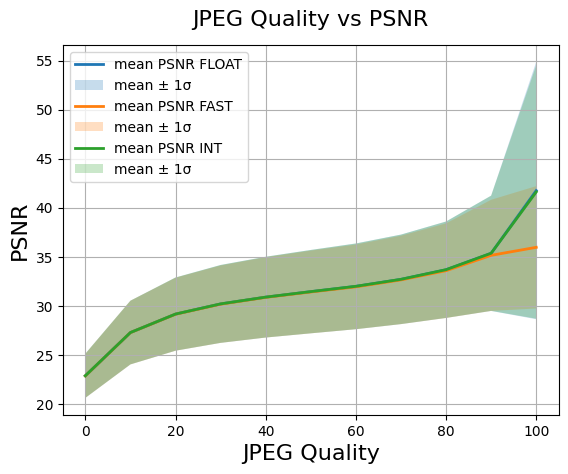

In [11]:
# Aggregate per quality across experiments
stats_float = (
    df[df["dct_algorithm"] == "float"].groupby("quality", as_index=False)["psnr"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_float["quality"].to_numpy()
m_float = stats_float["mean"].to_numpy()
s_float = stats_float["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_float = np.nan_to_num(s_float, nan=0.0)

stats_fast = (
    df[df["dct_algorithm"] == "fast"].groupby("quality", as_index=False)["psnr"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_fast = stats_fast["mean"].to_numpy()
s_fast = stats_fast["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_fast = np.nan_to_num(s_fast, nan=0.0)

stats_int = (
    df[df["dct_algorithm"] == "int"].groupby("quality", as_index=False)["psnr"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_int = stats_int["mean"].to_numpy()
s_int = stats_int["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_int = np.nan_to_num(s_int, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs PSNR", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("PSNR", fontsize=16)
ax.grid(True)

ax.plot(x, m_float, label="mean PSNR FLOAT", linewidth=2)
ax.fill_between(x, m_float - s_float, m_float + s_float, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_fast, label="mean PSNR FAST", linewidth=2)
ax.fill_between(x, m_fast - s_fast, m_fast + s_fast, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_int, label="mean PSNR INT", linewidth=2)
ax.fill_between(x, m_int - s_int, m_int + s_int, alpha=0.25, label="mean ± 1σ")


ax.legend()
plt.show()

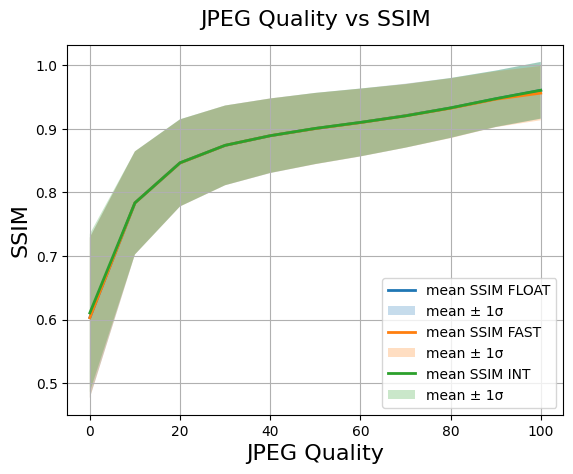

In [12]:
# Aggregate per quality across experiments
stats_float = (
    df[df["dct_algorithm"] == "float"].groupby("quality", as_index=False)["ssim"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_float["quality"].to_numpy()
m_float = stats_float["mean"].to_numpy()
s_float = stats_float["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_float = np.nan_to_num(s_float, nan=0.0)

stats_fast = (
    df[df["dct_algorithm"] == "fast"].groupby("quality", as_index=False)["ssim"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_fast = stats_fast["mean"].to_numpy()
s_fast = stats_fast["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_fast = np.nan_to_num(s_fast, nan=0.0)

stats_int = (
    df[df["dct_algorithm"] == "int"].groupby("quality", as_index=False)["ssim"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_int = stats_int["mean"].to_numpy()
s_int = stats_int["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_int = np.nan_to_num(s_int, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs SSIM", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("SSIM", fontsize=16)
ax.grid(True)

ax.plot(x, m_float, label="mean SSIM FLOAT", linewidth=2)
ax.fill_between(x, m_float - s_float, m_float + s_float, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_fast, label="mean SSIM FAST", linewidth=2)
ax.fill_between(x, m_fast - s_fast, m_fast + s_fast, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_int, label="mean SSIM INT", linewidth=2)
ax.fill_between(x, m_int - s_int, m_int + s_int, alpha=0.25, label="mean ± 1σ")


ax.legend()
plt.show()

## Format vs. File Size


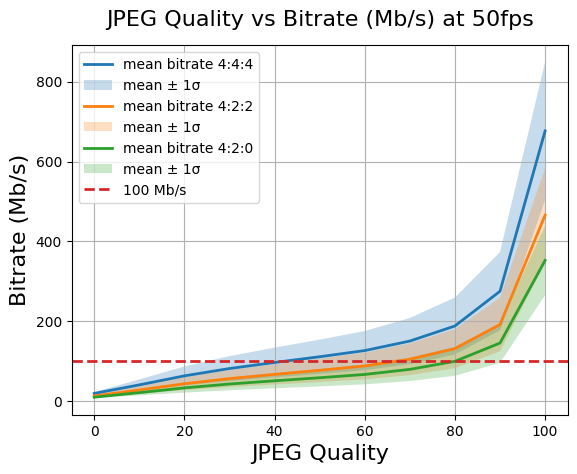

In [13]:
# Aggregate per quality across experiments
stats_444 = (
    df[df["subsampling"] == 444].groupby("quality", as_index=False)["compressed_size_bytes"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_444["quality"].to_numpy()
m_444 = stats_444["mean"].to_numpy()  * 50 * 8 / 1_000_000
s_444 = stats_444["std"].to_numpy()  * 50 * 8 / 1_000_000

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_444 = np.nan_to_num(s_444, nan=0.0)

stats_422 = (
    df[df["subsampling"] == 422].groupby("quality", as_index=False)["compressed_size_bytes"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_422 = stats_422["mean"].to_numpy()  * 50 * 8 / 1_000_000
s_422 = stats_422["std"].to_numpy()  * 50 * 8 / 1_000_000

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_422 = np.nan_to_num(s_422, nan=0.0)

stats_420 = (
    df[df["subsampling"] == 420].groupby("quality", as_index=False)["compressed_size_bytes"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_420 = stats_420["mean"].to_numpy()  * 50 * 8 / 1_000_000
s_420 = stats_420["std"].to_numpy()  * 50 * 8 / 1_000_000

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_420 = np.nan_to_num(s_420, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Bitrate (Mb/s) at 50fps", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Bitrate (Mb/s)", fontsize=16)
ax.grid(True)

ax.plot(x, m_444, label="mean bitrate 4:4:4", linewidth=2)
ax.fill_between(x, m_444 - s_444, m_444 + s_444, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_422, label="mean bitrate 4:2:2", linewidth=2)
ax.fill_between(x, m_422 - s_422, m_422 + s_422, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_420, label="mean bitrate 4:2:0", linewidth=2)
ax.fill_between(x, m_420 - s_420, m_420 + s_420, alpha=0.25, label="mean ± 1σ")

ax.axhline(100, color="tab:red",   linestyle="--", linewidth=2, label="100 Mb/s")


ax.legend()
plt.show()

We can observe an explosion in file size from quality 95 onwards, and a sharp increase from quality 90 onwards.

## Encoding Parameters vs. Performance

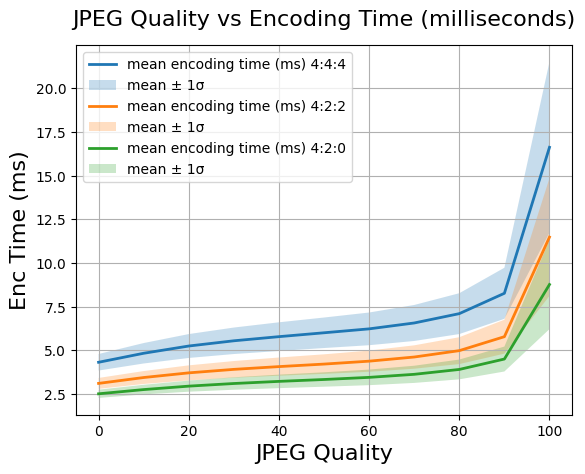

In [14]:
# Aggregate per quality across experiments
stats_444 = (
    df[df["subsampling"] == 444].groupby("quality", as_index=False)["enc_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_444["quality"].to_numpy()
m_444 = stats_444["mean"].to_numpy()
s_444 = stats_444["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_444 = np.nan_to_num(s_444, nan=0.0)

stats_422 = (
    df[df["subsampling"] == 422].groupby("quality", as_index=False)["enc_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_422 = stats_422["mean"].to_numpy()
s_422 = stats_422["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_422 = np.nan_to_num(s_422, nan=0.0)

stats_420 = (
    df[df["subsampling"] == 420].groupby("quality", as_index=False)["enc_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_420 = stats_420["mean"].to_numpy()
s_420 = stats_420["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_420 = np.nan_to_num(s_420, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Encoding Time (milliseconds)", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Enc Time (ms)", fontsize=16)
ax.grid(True)

ax.plot(x, m_444, label="mean encoding time (ms) 4:4:4", linewidth=2)
ax.fill_between(x, m_444 - s_444, m_444 + s_444, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_422, label="mean encoding time (ms) 4:2:2", linewidth=2)
ax.fill_between(x, m_422 - s_422, m_422 + s_422, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_420, label="mean encoding time (ms) 4:2:0", linewidth=2)
ax.fill_between(x, m_420 - s_420, m_420 + s_420, alpha=0.25, label="mean ± 1σ")

ax.legend()
plt.show()

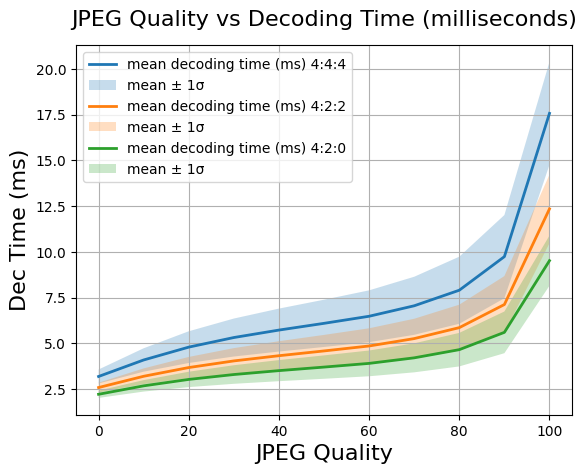

In [15]:
# Aggregate per quality across experiments
stats_444 = (
    df[df["subsampling"] == 444].groupby("quality", as_index=False)["dec_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_444["quality"].to_numpy()
m_444 = stats_444["mean"].to_numpy()
s_444 = stats_444["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_444 = np.nan_to_num(s_444, nan=0.0)

stats_422 = (
    df[df["subsampling"] == 422].groupby("quality", as_index=False)["dec_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_422 = stats_422["mean"].to_numpy()
s_422 = stats_422["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_422 = np.nan_to_num(s_422, nan=0.0)

stats_420 = (
    df[df["subsampling"] == 420].groupby("quality", as_index=False)["dec_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_420 = stats_420["mean"].to_numpy()
s_420 = stats_420["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_420 = np.nan_to_num(s_420, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Decoding Time (milliseconds)", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Dec Time (ms)", fontsize=16)
ax.grid(True)

ax.plot(x, m_444, label="mean decoding time (ms) 4:4:4", linewidth=2)
ax.fill_between(x, m_444 - s_444, m_444 + s_444, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_422, label="mean decoding time (ms) 4:2:2", linewidth=2)
ax.fill_between(x, m_422 - s_422, m_422 + s_422, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_420, label="mean decoding time (ms) 4:2:0", linewidth=2)
ax.fill_between(x, m_420 - s_420, m_420 + s_420, alpha=0.25, label="mean ± 1σ")

ax.legend()
plt.show()

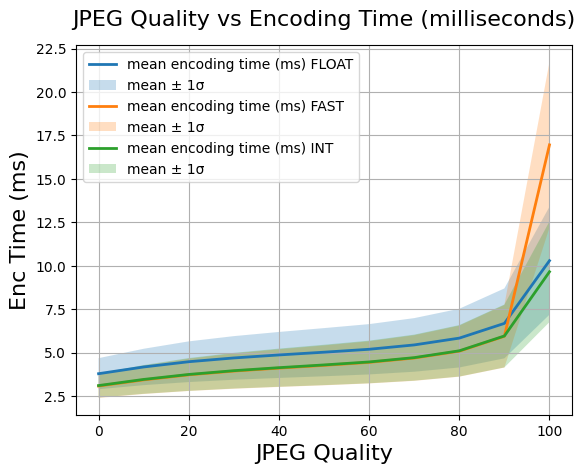

In [16]:
# Aggregate per quality across experiments
stats_float = (
    df[df["dct_algorithm"] == "float"].groupby("quality", as_index=False)["enc_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_float["quality"].to_numpy()
m_float = stats_float["mean"].to_numpy()
s_float = stats_float["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_float = np.nan_to_num(s_float, nan=0.0)

stats_fast = (
    df[df["dct_algorithm"] == "fast"].groupby("quality", as_index=False)["enc_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_fast = stats_fast["mean"].to_numpy()
s_fast = stats_fast["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_fast = np.nan_to_num(s_fast, nan=0.0)

stats_int = (
    df[df["dct_algorithm"] == "int"].groupby("quality", as_index=False)["enc_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_int = stats_int["mean"].to_numpy()
s_int = stats_int["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_int = np.nan_to_num(s_int, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Encoding Time (milliseconds)", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Enc Time (ms)", fontsize=16)
ax.grid(True)

ax.plot(x, m_float, label="mean encoding time (ms) FLOAT", linewidth=2)
ax.fill_between(x, m_float - s_float, m_float + s_float, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_fast, label="mean encoding time (ms) FAST", linewidth=2)
ax.fill_between(x, m_fast - s_fast, m_fast + s_fast, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_int, label="mean encoding time (ms) INT", linewidth=2)
ax.fill_between(x, m_int - s_int, m_int + s_int, alpha=0.25, label="mean ± 1σ")

ax.legend()
plt.show()

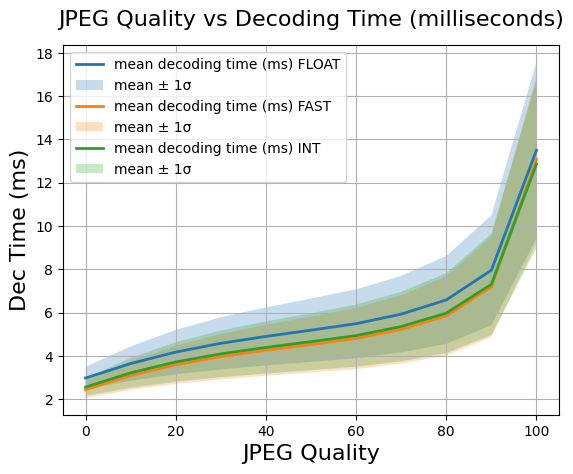

In [17]:
# Aggregate per quality across experiments
stats_float = (
    df[df["dct_algorithm"] == "float"].groupby("quality", as_index=False)["dec_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_float["quality"].to_numpy()
m_float = stats_float["mean"].to_numpy()
s_float = stats_float["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_float = np.nan_to_num(s_float, nan=0.0)

stats_fast = (
    df[df["dct_algorithm"] == "fast"].groupby("quality", as_index=False)["dec_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_fast = stats_fast["mean"].to_numpy()
s_fast = stats_fast["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_fast = np.nan_to_num(s_fast, nan=0.0)

stats_int = (
    df[df["dct_algorithm"] == "int"].groupby("quality", as_index=False)["dec_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_int = stats_int["mean"].to_numpy()
s_int = stats_int["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_int = np.nan_to_num(s_int, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Decoding Time (milliseconds)", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Dec Time (ms)", fontsize=16)
ax.grid(True)

ax.plot(x, m_float, label="mean decoding time (ms) FLOAT", linewidth=2)
ax.fill_between(x, m_float - s_float, m_float + s_float, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_fast, label="mean decoding time (ms) FAST", linewidth=2)
ax.fill_between(x, m_fast - s_fast, m_fast + s_fast, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_int, label="mean decoding time (ms) INT", linewidth=2)
ax.fill_between(x, m_int - s_int, m_int + s_int, alpha=0.25, label="mean ± 1σ")

ax.legend()
plt.show()

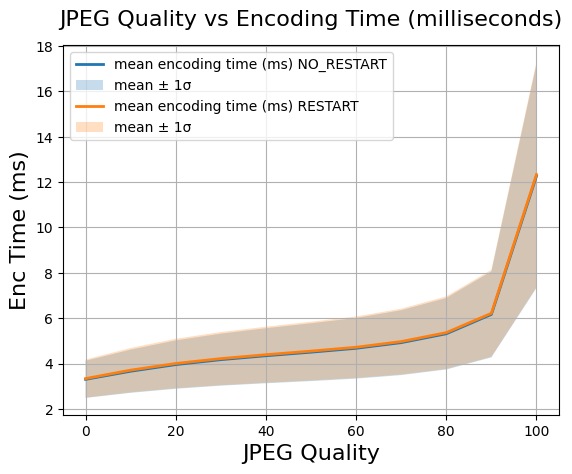

In [18]:
# Aggregate per quality across experiments
stats_norest = (
    df[df["restart_interval"] == 0].groupby("quality", as_index=False)["enc_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_norest["quality"].to_numpy()
m_norest = stats_norest["mean"].to_numpy()
s_norest = stats_norest["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_norest = np.nan_to_num(s_norest, nan=0.0)

stats_rest = (
    df[df["restart_interval"] != 0].groupby("quality", as_index=False)["enc_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_rest = stats_rest["mean"].to_numpy()
s_rest = stats_rest["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_rest = np.nan_to_num(s_rest, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Encoding Time (milliseconds)", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Enc Time (ms)", fontsize=16)
ax.grid(True)

ax.plot(x, m_norest, label="mean encoding time (ms) NO_RESTART", linewidth=2)
ax.fill_between(x, m_norest - s_norest, m_norest + s_norest, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_rest, label="mean encoding time (ms) RESTART", linewidth=2)
ax.fill_between(x, m_rest - s_rest, m_rest + s_rest, alpha=0.25, label="mean ± 1σ")

ax.legend()
plt.show()

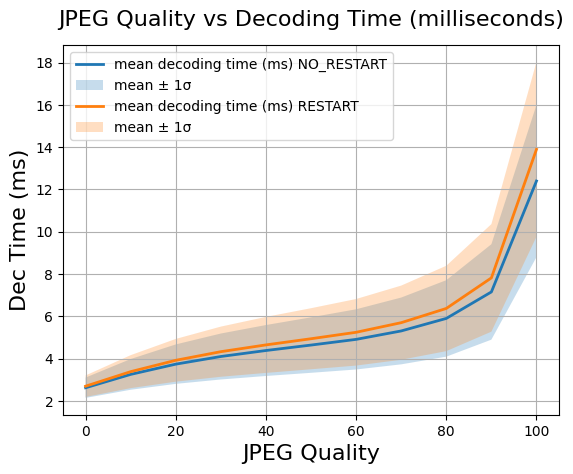

In [21]:
# Aggregate per quality across experiments
stats_norest = (
    df[df["restart_interval"] == 0].groupby("quality", as_index=False)["dec_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_norest["quality"].to_numpy()
m_norest = stats_norest["mean"].to_numpy()
s_norest = stats_norest["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_norest = np.nan_to_num(s_norest, nan=0.0)

stats_rest = (
    df[df["restart_interval"] != 0].groupby("quality", as_index=False)["dec_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_rest = stats_rest["mean"].to_numpy()
s_rest = stats_rest["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_rest = np.nan_to_num(s_rest, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Decoding Time (milliseconds)", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Dec Time (ms)", fontsize=16)
ax.grid(True)

ax.plot(x, m_norest, label="mean decoding time (ms) NO_RESTART", linewidth=2)
ax.fill_between(x, m_norest - s_norest, m_norest + s_norest, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_rest, label="mean decoding time (ms) RESTART", linewidth=2)
ax.fill_between(x, m_rest - s_rest, m_rest + s_rest, alpha=0.25, label="mean ± 1σ")

ax.legend()
plt.show()

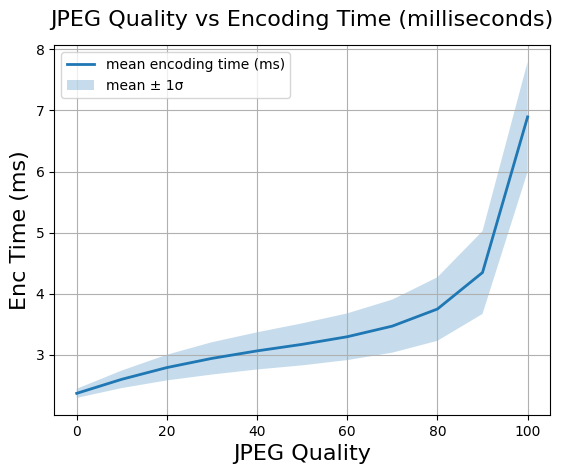

In [25]:
# Aggregate per quality across experiments
stats = (
    df[(df["dct_algorithm"] == "int") & (df["subsampling"] == 420) & (df["restart_interval"] == 0)].groupby("quality", as_index=False)["enc_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats["quality"].to_numpy()
m = stats["mean"].to_numpy()
s = stats["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s = np.nan_to_num(s, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Encoding Time (milliseconds)", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Enc Time (ms)", fontsize=16)
ax.grid(True)

ax.plot(x, m, label="mean encoding time (ms)", linewidth=2)
ax.fill_between(x, m - s, m + s, alpha=0.25, label="mean ± 1σ")
ax.legend()
plt.show()

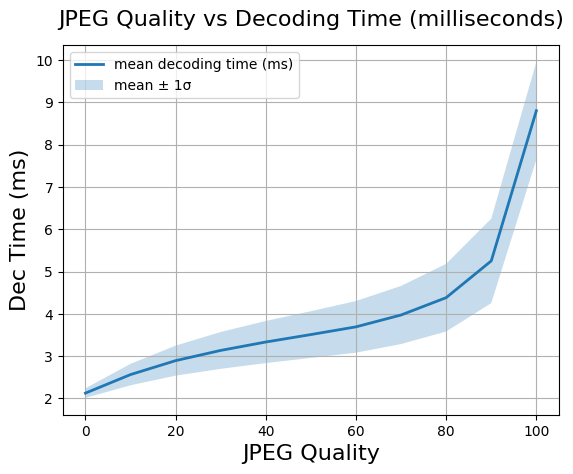

In [23]:
# Aggregate per quality across experiments
stats = (
    df[(df["dct_algorithm"] == "int") & (df["subsampling"] == 420) & (df["restart_interval"] == 0)].groupby("quality", as_index=False)["dec_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats["quality"].to_numpy()
m = stats["mean"].to_numpy()
s = stats["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s = np.nan_to_num(s, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Decoding Time (milliseconds)", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Dec Time (ms)", fontsize=16)
ax.grid(True)

ax.plot(x, m, label="mean decoding time (ms)", linewidth=2)
ax.fill_between(x, m - s, m + s, alpha=0.25, label="mean ± 1σ")
ax.legend()
plt.show()

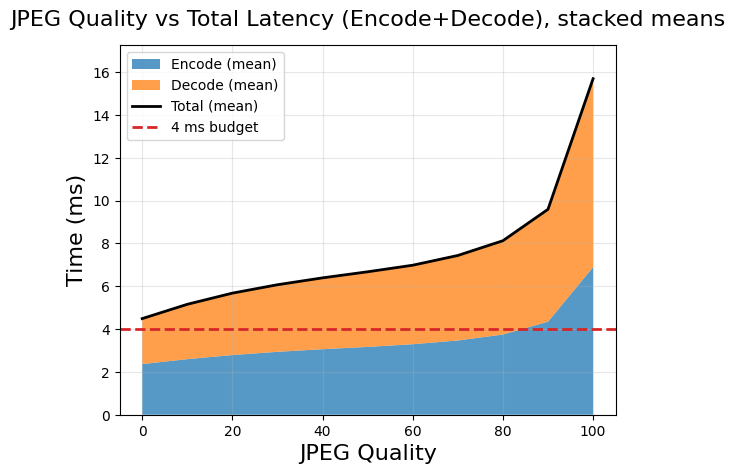

In [24]:
# Aggregate both metrics per quality (means + stds, in case you want them later)
stats = (
    df[(df["dct_algorithm"] == "int") & (df["subsampling"] == 420) & (df["restart_interval"] == 0)].groupby("quality", as_index=False)
      .agg(enc_mean=("enc_avg_time_milliseconds", "mean"),
           enc_std =("enc_avg_time_milliseconds", "std"),
           dec_mean=("dec_avg_time_milliseconds", "mean"),
           dec_std =("dec_avg_time_milliseconds", "std"))
      .sort_values("quality")
)

q   = stats["quality"].to_numpy()
enc = stats["enc_mean"].to_numpy()
dec = stats["dec_mean"].to_numpy()

total = enc + dec

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Total Latency (Encode+Decode), stacked means", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Time (ms)", fontsize=16)
ax.grid(True, alpha=0.3)

# Stacked mean areas
ax.stackplot(q, enc, dec, labels=["Encode (mean)", "Decode (mean)"], alpha=0.75)

# Total mean line (optional but usually useful)
ax.plot(q, total, color="black", linewidth=2, label="Total (mean)")

# 4 ms total latency budget
ax.axhline(4.0, color="tab:red", linestyle="--", linewidth=2, label="4 ms budget")

# Make sure budget line is visible
ax.set_ylim(bottom=0, top=max(total.max(), 4.0) * 1.1)

ax.legend(loc="upper left")
plt.show()